In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob

%matplotlib inline



In [14]:
# Step 1: Load Data
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")
stock_df = pd.read_csv("../data/AAPL.csv")

# Quick check of the data
print("News Data Sample:")
display(news_df.head())

print("Stock Data Sample:")
display(stock_df.head())


News Data Sample:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Stock Data Sample:


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [15]:
# Headline length
news_df['headline_length'] = news_df['headline'].apply(len)
print("Headline Length Statistics:")
display(news_df['headline_length'].describe())

# Articles per publisher
print("\nTop 10 Publishers by Number of Articles:")
display(news_df['publisher'].value_counts().head(10))


Headline Length Statistics:


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


Top 10 Publishers by Number of Articles:


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

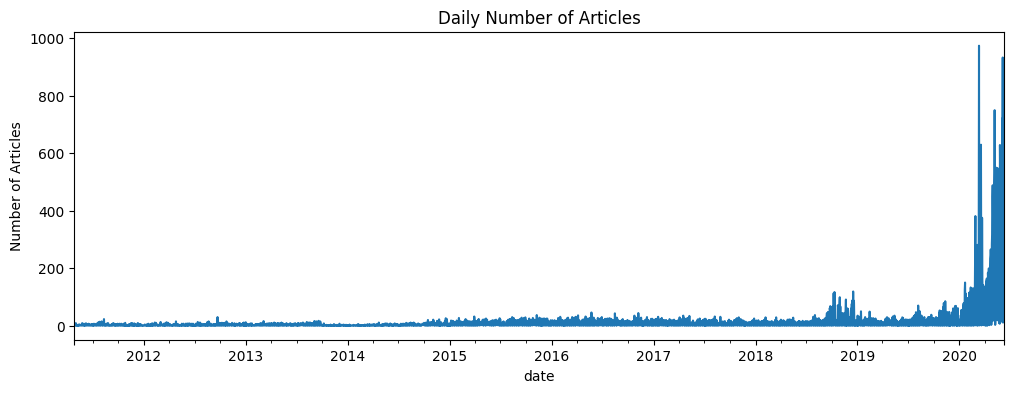

In [17]:
# Convert dates to datetime (let pandas infer format)
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')  # convert invalids to NaT
news_df = news_df.dropna(subset=['date'])  # remove rows where date couldn't be parsed
news_df.set_index('date', inplace=True)

# Daily article counts
daily_articles = news_df['headline'].resample('D').count()
plt.figure(figsize=(12,4))
daily_articles.plot()
plt.title("Daily Number of Articles")
plt.ylabel("Number of Articles")
plt.show()



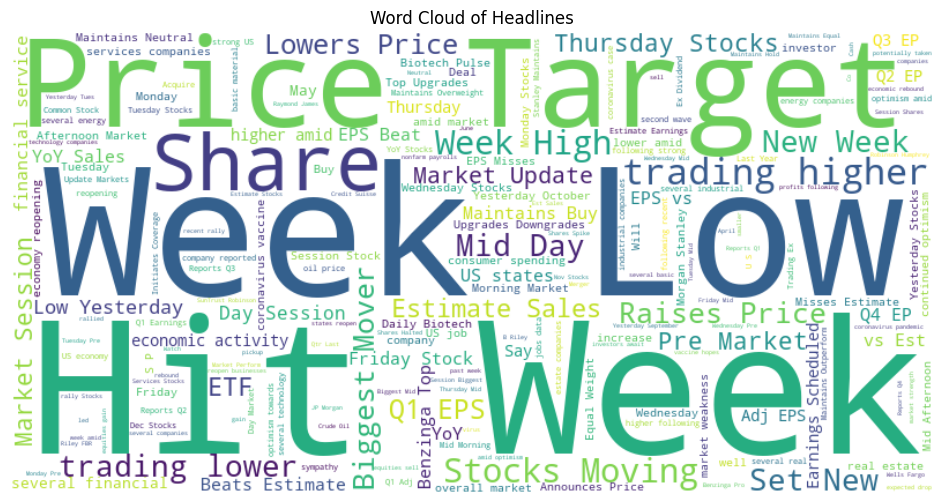

In [18]:
# Generate a word cloud of headlines
all_headlines = " ".join(news_df['headline'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_headlines)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Headlines")
plt.show()


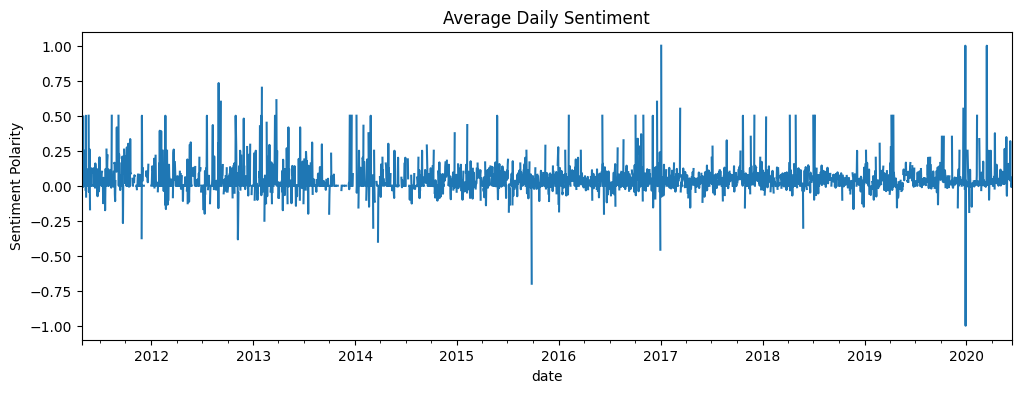

In [19]:
# Function to get sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

news_df['sentiment'] = news_df['headline'].apply(get_sentiment)

# Average daily sentiment
daily_sentiment = news_df['sentiment'].resample('D').mean()
plt.figure(figsize=(12,4))
daily_sentiment.plot()
plt.title("Average Daily Sentiment")
plt.ylabel("Sentiment Polarity")
plt.show()


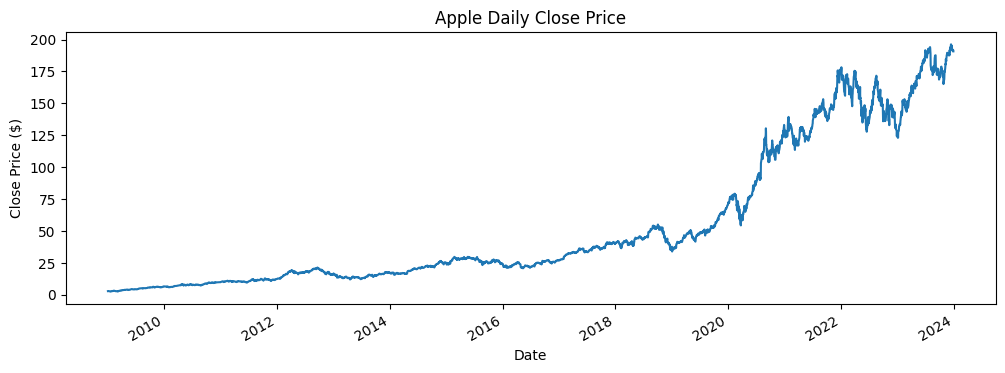

In [23]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df.set_index('Date', inplace=True)  # Capital D to match the column

plt.figure(figsize=(12,4))
stock_df['Close'].plot(title="Apple Daily Close Price")
plt.ylabel("Close Price ($)")
plt.show()



In [21]:
print(stock_df.columns)


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [24]:
merged_df = pd.merge(stock_df, daily_sentiment, left_index=True, right_index=True, how='inner')

plt.figure(figsize=(12,6))
merged_df[['Close', 'sentiment']].plot(subplots=True)
plt.show()

# Optional: save merged data
merged_df.to_csv("../data/merged_stock_news.csv")
print("Merged dataset saved to data/merged_stock_news.csv")


TypeError: Cannot join tz-naive with tz-aware DatetimeIndex

<Figure size 1200x600 with 0 Axes>

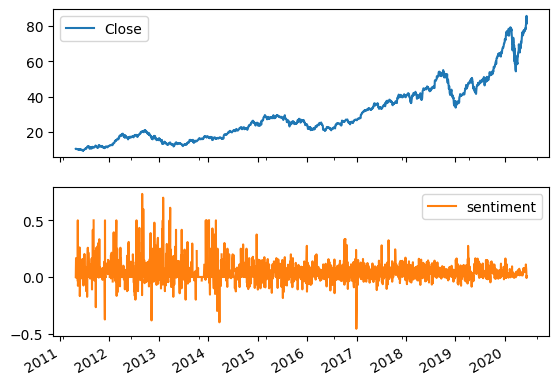

In [25]:
# Remove timezone info from daily_sentiment
daily_sentiment.index = daily_sentiment.index.tz_localize(None)

# Make sure stock_df index is timezone-naive as well
stock_df.index = stock_df.index.tz_localize(None) if stock_df.index.tzinfo else stock_df.index

# Now merge
merged_df = pd.merge(stock_df, daily_sentiment, left_index=True, right_index=True, how='inner')

plt.figure(figsize=(12,6))
merged_df[['Close', 'sentiment']].plot(subplots=True)
plt.show()
